<a href="https://colab.research.google.com/github/daniafzc/tugas1pcd/blob/main/PCD_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install scikit-image opencv-python-headless

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os

In [3]:
os.makedirs('images', exist_ok = True)
os.makedirs('outputs', exist_ok = True)

In [5]:
astronaut = img_as_ubyte(data.astronaut())
checkerboard = cv2.cvtColor(img_as_ubyte(data.checkerboard()), cv2.COLOR_GRAY2RGB)
cameraman = cv2.cvtColor(img_as_ubyte(data.camera()), cv2.COLOR_GRAY2RGB)
coins = cv2.cvtColor(img_as_ubyte(data.coins()), cv2.COLOR_GRAY2RGB)

In [7]:
cv2.imwrite('images/astronaut.png',  )
cv2.imwrite('images/checkerboard.png', cv2.cvtColor(checkerboard, cv2.COLOR_RGB2BGR))
cv2.imwrite('images/cameraman.png', cv2.cvtColor(cameraman, cv2.COLOR_RGB2BGR))
cv2.imwrite('images/coins.png', cv2.cvtColor(coins, cv2.COLOR_RGB2BGR))

True

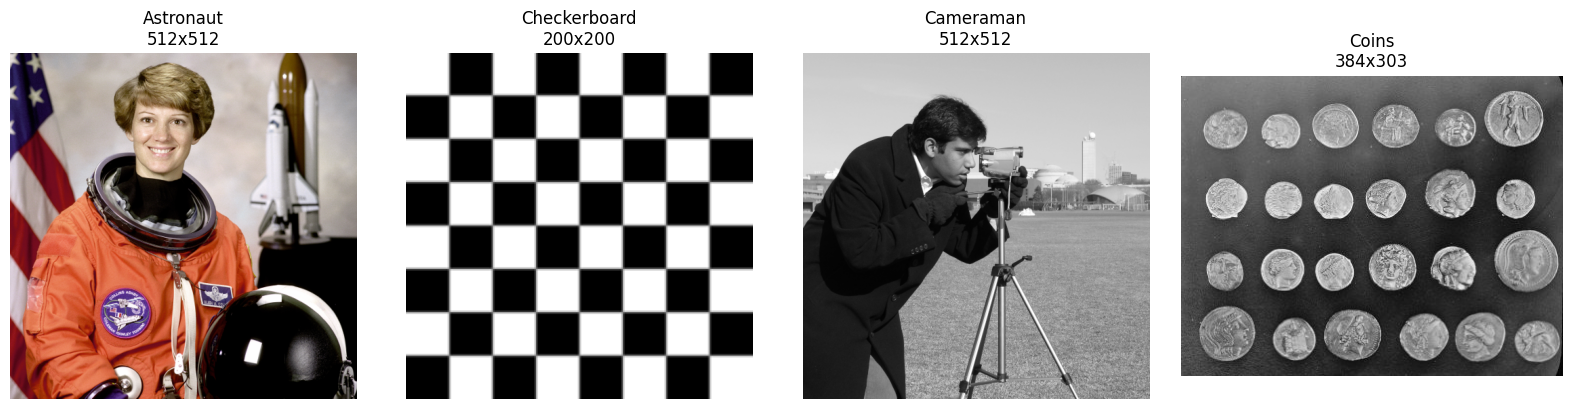

In [14]:
IMAGES = {
    'Astronaut' : astronaut,
    'Checkerboard' : checkerboard,
    'Cameraman' : cameraman,
    'Coins' : coins
}

fug, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (label, im) in zip(axes, IMAGES.items()):
  ax.imshow(im); ax.set_title(f"{label}\n{im.shape[1]}x{im.shape[0]}"); ax.axis('off')
plt.tight_layout(); plt.show()

## 2. Down Sampling
* Max Pooling: mengambi pixel paling terang --> mempertahankan highlight/edges, cenderung brighten image.
* Average Pooling: mengambil mean --> berperan sebagai low-pass (blur) filter sebelum subsampling, mengurangi aliasing
* Median Pooling: mengambil median --> mirip efek smoothing to average, tapi lebih reboust terhadap outliers/noise values.


In [20]:
def _crop_to_multiple(img, factor):
  h, w = img.shape[:2]
  h2, w2 = (h // factor) * factor, (w // factor) * factor
  return img[:h2, :w2]

def _to_blocks(channel, factor):
  h, w = channel.shape
  return channel.reshape(h // factor, factor, w // factor, factor).swapaxes(1, 2)

def downsample(img, factor, method='max'):
  """Manual block-based downsampling. method: 'max' | 'avg' | ' median'."""
  img = _crop_to_multiple(img, factor)
  if img.ndim == 2:
    blocks = _to_blocks(img.astype(np.float64), factor)
    if method == 'max':
      out = blocks.max(axis=(2, 3))
    elif method == 'avg':
      out = blocks.mean(axis=(2, 3))
    elif method == 'median':
      out = np.median(blocks, axis=(2, 3))
    else:
      raise ValueError(method)
    return np.clip(out, 0, 255).astype(np.uint8)
  else:
    return np.stack([downsample(img[:, :, c], factor, method) for c in range(img.shape[2])], axis=2)

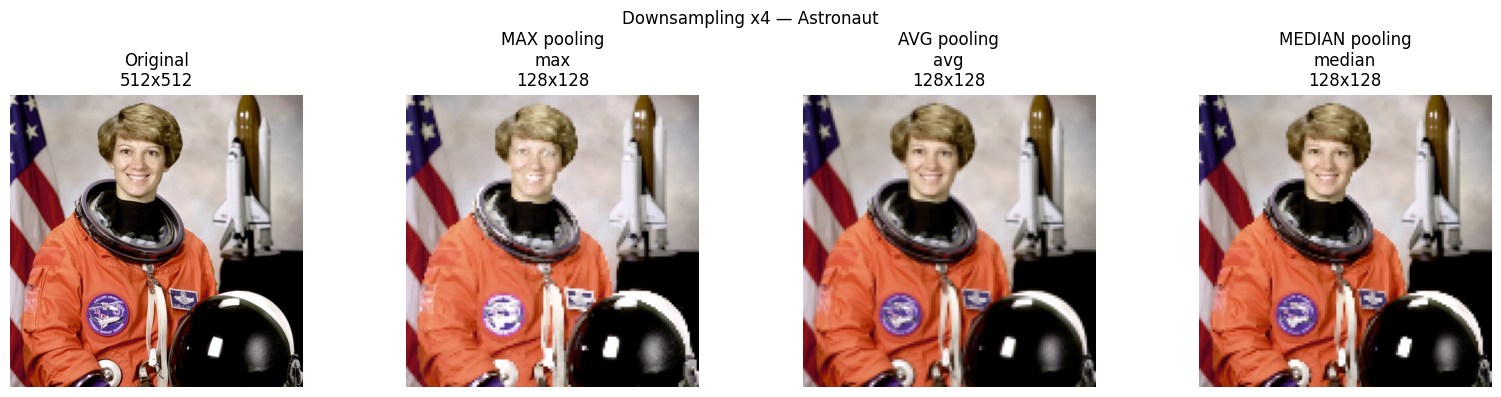

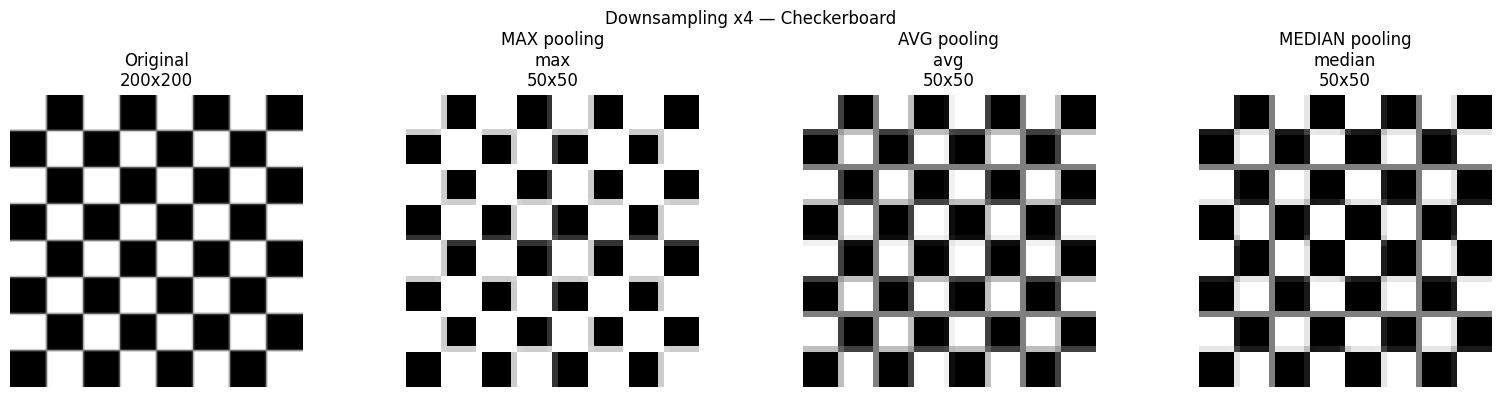

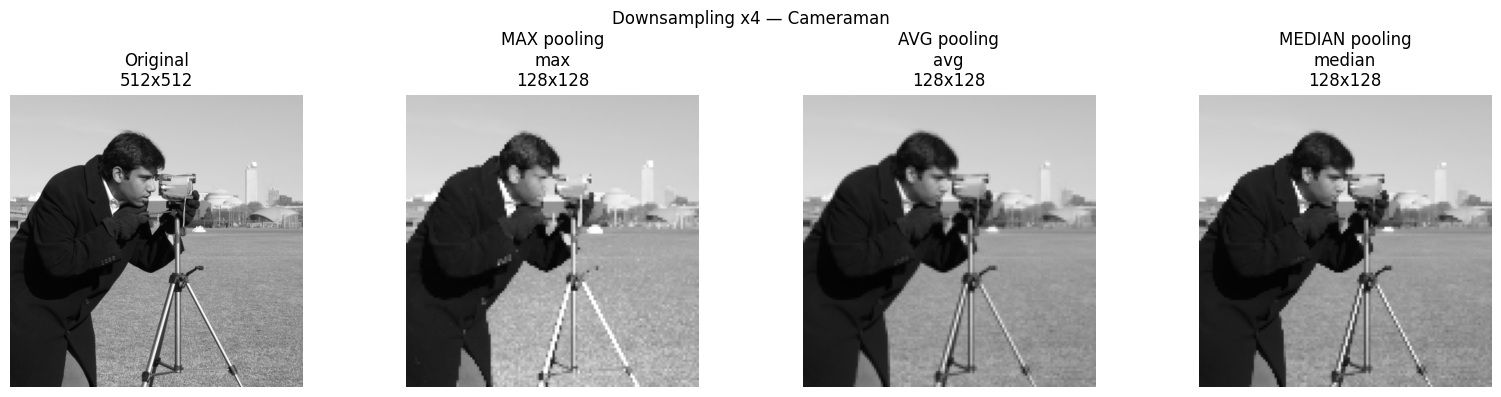

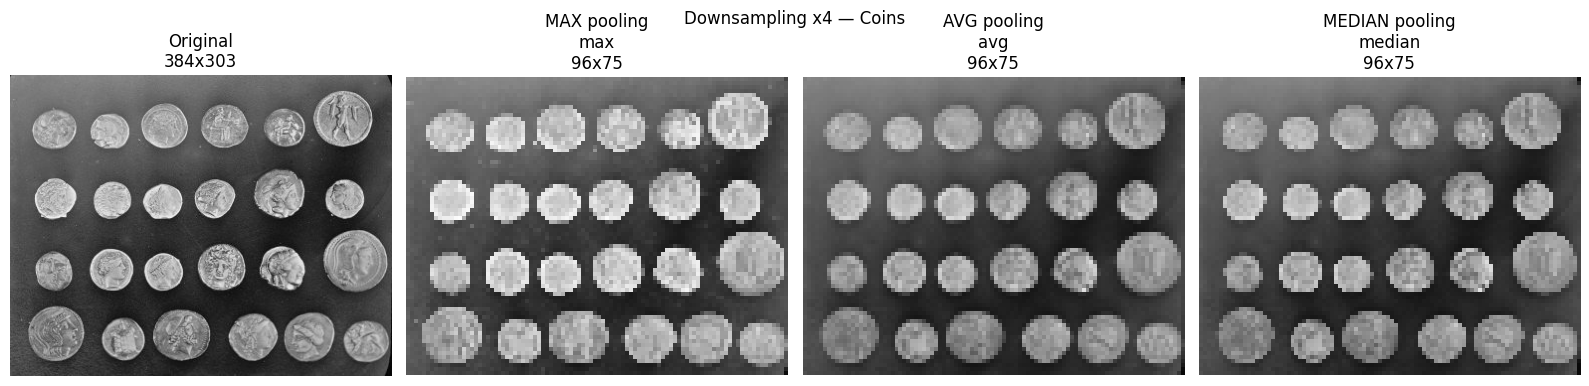

In [21]:
FACTOR = 4
DOWN_METHODS = ['max', 'avg', 'median']

for label, im in IMAGES.items():
  fig, axes = plt.subplots(1, 4, figsize=(16,4))
  axes[0].imshow(im); axes[0].set_title(f'Original\n{im.shape[1]}x{im.shape[0]}'); axes[0].axis('off')
  for i, m in enumerate(DOWN_METHODS):
    d = downsample(im, FACTOR, m)
    axes[i+1].imshow(d); axes[i+1].set_title(f'{m.upper()} pooling\n{m}\n{d.shape[1]}x{d.shape[0]}'); axes[i+1].axis('off')
  plt.suptitle(f'Downsampling x{FACTOR} — {label}')
  plt.tight_layout()
  plt.savefig(f"outputs/downsample_{label.split(' ')[0].lower()}.png", dpi=110, bbox_inches='tight')
  plt.show()

## 3. Up Sampling
* Nearest Neighbor: copy value pixel terdekat --> cepat, tetapi hasilnya blocky
* Bilinear: interpolasi linear menggunakan 4 nearest neighbors (2x2 window) --> lebih smooth, blur sedang
* Bicubic: interpolasi menggunakan ketetanggan 4x4 dengan kernel cubic --> gardien lebih smooth, dan edges lebih tajam daripada bilinear, namun compute cost nya lebih boros

In [22]:
def upsample(img, factor, method='nn'):
    h, w = img.shape[:2]
    new_size = (w * factor, h * factor)
    flag = {'nn': cv2.INTER_NEAREST, 'bilinear': cv2.INTER_LINEAR, 'bicubic': cv2.INTER_CUBIC}[method]
    return cv2.resize(img, new_size, interpolation=flag)

def compute_metrics(orig, recon):
    orig_c = orig[:recon.shape[0], :recon.shape[1]]
    p = psnr(orig_c, recon, data_range=255)
    s = ssim(orig_c, recon, channel_axis=2, data_range=255)
    return p, s


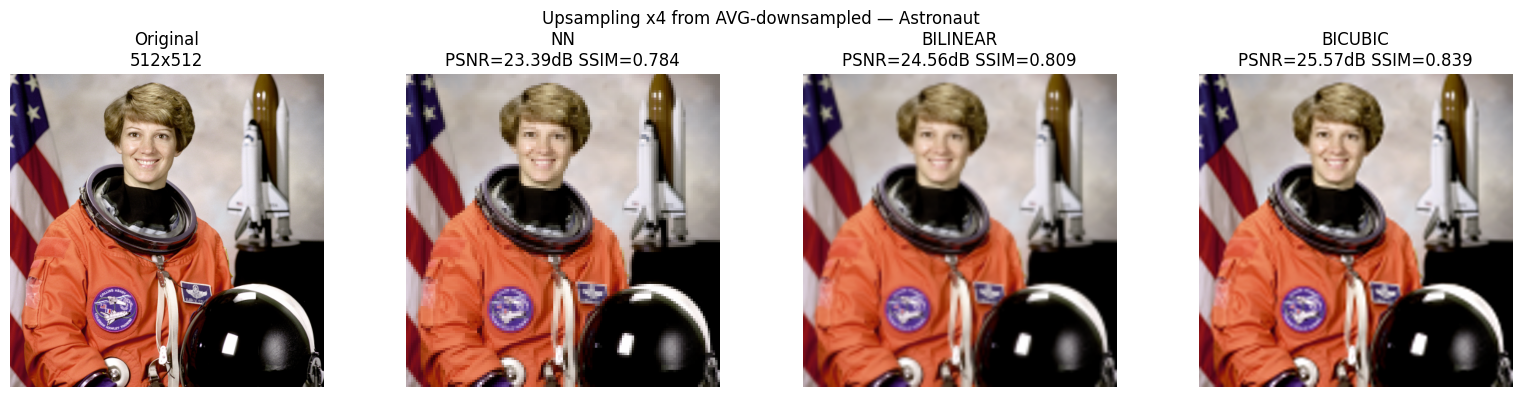

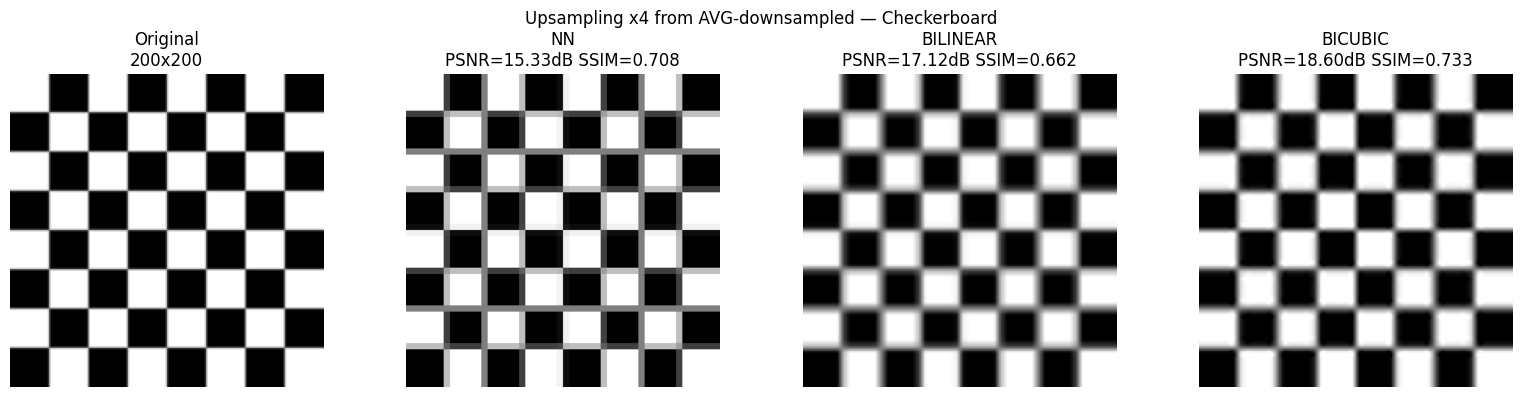

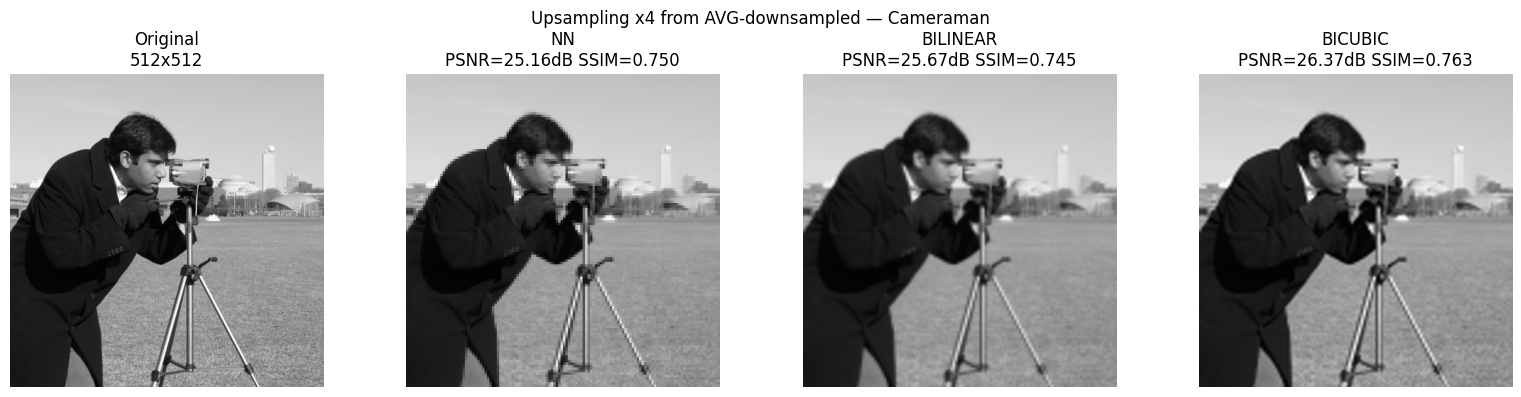

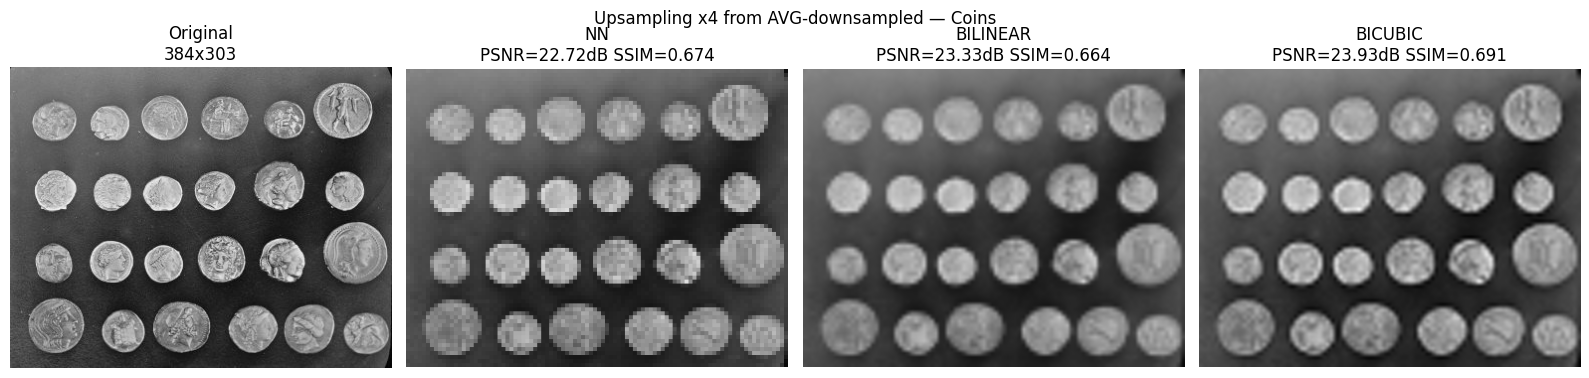

In [23]:
UP_METHODS = ['nn', 'bilinear', 'bicubic']
metrics_table = []

for label, im in IMAGES.items():
    im_small = downsample(im, FACTOR, 'avg')  # low-res source to reconstruct from
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(im); axes[0].set_title(f'Original\n{im.shape[1]}x{im.shape[0]}'); axes[0].axis('off')
    for i, m in enumerate(UP_METHODS):
        u = upsample(im_small, FACTOR, m)
        p, s = compute_metrics(im, u)
        axes[i+1].imshow(u); axes[i+1].set_title(f'{m.upper()}\nPSNR={p:.2f}dB SSIM={s:.3f}'); axes[i+1].axis('off')
        metrics_table.append((label, m, p, s))
    plt.suptitle(f'Upsampling x{FACTOR} from AVG-downsampled — {label}')
    plt.tight_layout()
    plt.savefig(f"outputs/upsample_{label.split(' ')[0].lower()}.png", dpi=110, bbox_inches='tight')
    plt.show()


## 4. Full Pipeline: Down x Up Combination Matrix

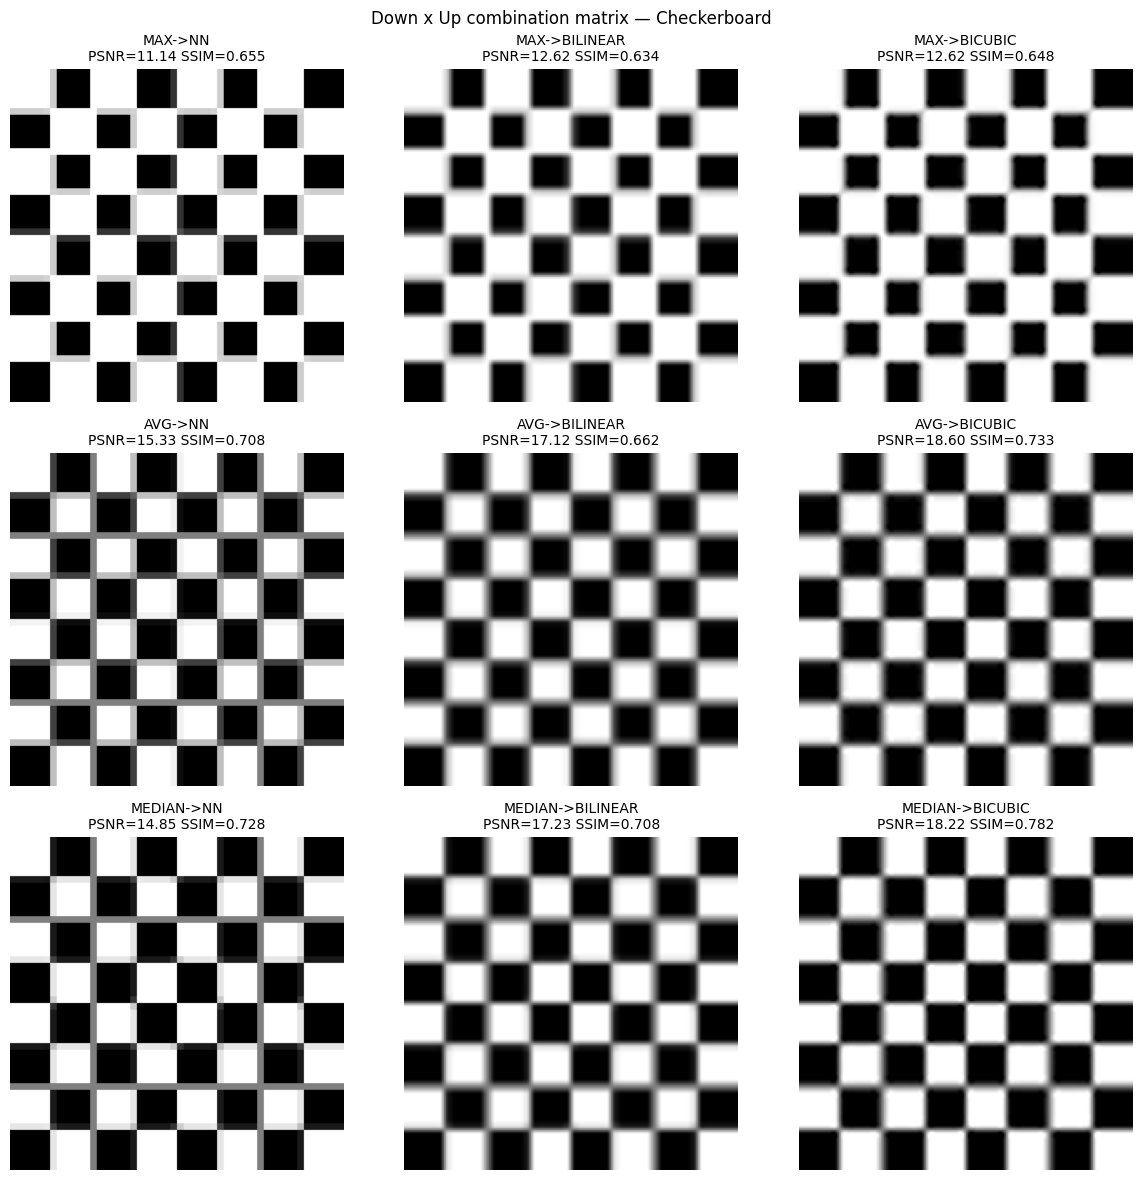

In [25]:
label = 'Checkerboard'
im = IMAGES[label]
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for r, dm in enumerate(DOWN_METHODS):
    small = downsample(im, FACTOR, dm)
    for c, um in enumerate(UP_METHODS):
        u = upsample(small, FACTOR, um)
        p, s = compute_metrics(im, u)
        axes[r, c].imshow(u)
        axes[r, c].set_title(f'{dm.upper()}->{um.upper()}\nPSNR={p:.2f} SSIM={s:.3f}', fontsize=10)
        axes[r, c].axis('off')
plt.suptitle(f'Down x Up combination matrix — {label}')
plt.tight_layout()
plt.savefig('outputs/matrix_checkerboard.png', dpi=110, bbox_inches='tight')
plt.show()


## 5. Quantitative Summary
PSNR (semakin tinggi semakin baik) dan SSIM (semakin tinggi semakin baik)

In [26]:
import pandas as pd
df = pd.DataFrame(metrics_table, columns=['Image', 'Upsample Method', 'PSNR (dB)', 'SSIM'])
df.to_csv('outputs/metrics.csv', index=False)
df_pivot = df.pivot(index='Image', columns='Upsample Method', values='PSNR (dB)')
print("PSNR (dB) — higher is better\n")
print(df_pivot.round(2))
df

PSNR (dB) — higher is better

Upsample Method  bicubic  bilinear     nn
Image                                    
Astronaut          25.57     24.56  23.39
Cameraman          26.37     25.67  25.16
Checkerboard       18.60     17.12  15.33
Coins              23.93     23.33  22.72


,Image,Upsample Method,PSNR (dB),SSIM
0,Astronaut,nn,23.393358,0.783623
1,Astronaut,bilinear,24.562969,0.809034
2,Astronaut,bicubic,25.567453,0.839090
3,Checkerboard,nn,15.326954,0.707645
4,Checkerboard,bilinear,17.123737,0.662095
5,Checkerboard,bicubic,18.598227,0.733099
6,Cameraman,nn,25.161092,0.749979
7,Cameraman,bilinear,25.673861,0.744628
8,Cameraman,bicubic,26.372677,0.762531
9,Coins,nn,22.715592,0.673701
